# 🌱 Smart Irrigation Model
Random Forest Regressor to predict pump run time (seconds) from sensor readings.

## 1 — Imports & Settings

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

sns.set_theme(style='whitegrid', palette='muted')

PUMP_MIN_TIME = 0
PUMP_MAX_TIME = 15
DATASET_PATH  = "farm_data.csv"
FEATURES = ['soil', 'temp', 'humidity', 'light', 'water_level', 'time_day']
TARGET   = 'pump_time'
print('Setup complete')

Setup complete


## 2 — Load / Generate Dataset

In [40]:

df = pd.read_csv(DATASET_PATH)
print(f'Dataset loaded: {df.shape}')
df['time_day'] = pd.to_datetime(df['time_day'], format='%H:%M').dt.hour

df.head(50)

Dataset loaded: (112, 7)


,soil,temp,humidity,light,water_level,time_day,pump_time
0,1937,12.8,83.6,320,79.3,0,0.0
1,2377,13.9,79.6,336,54.5,3,0.0
2,2828,18.2,60.3,1682,93.3,6,0.0
3,959,23.0,36.7,4262,50.5,9,10.5
4,971,22.6,38.7,4497,59.5,12,10.9
5,1115,25.6,43.1,4114,50.4,15,11.9
6,2761,19.7,56.5,572,89.5,18,0.0
7,1931,11.6,79.1,327,80.1,21,0.0
8,1835,12.7,85.2,321,56.2,0,0.0
9,1910,13.0,76.8,320,47.6,3,0.0


## 3 — Exploratory Data Analysis

### 3a — Target Distribution

### 3b — Feature Distributions

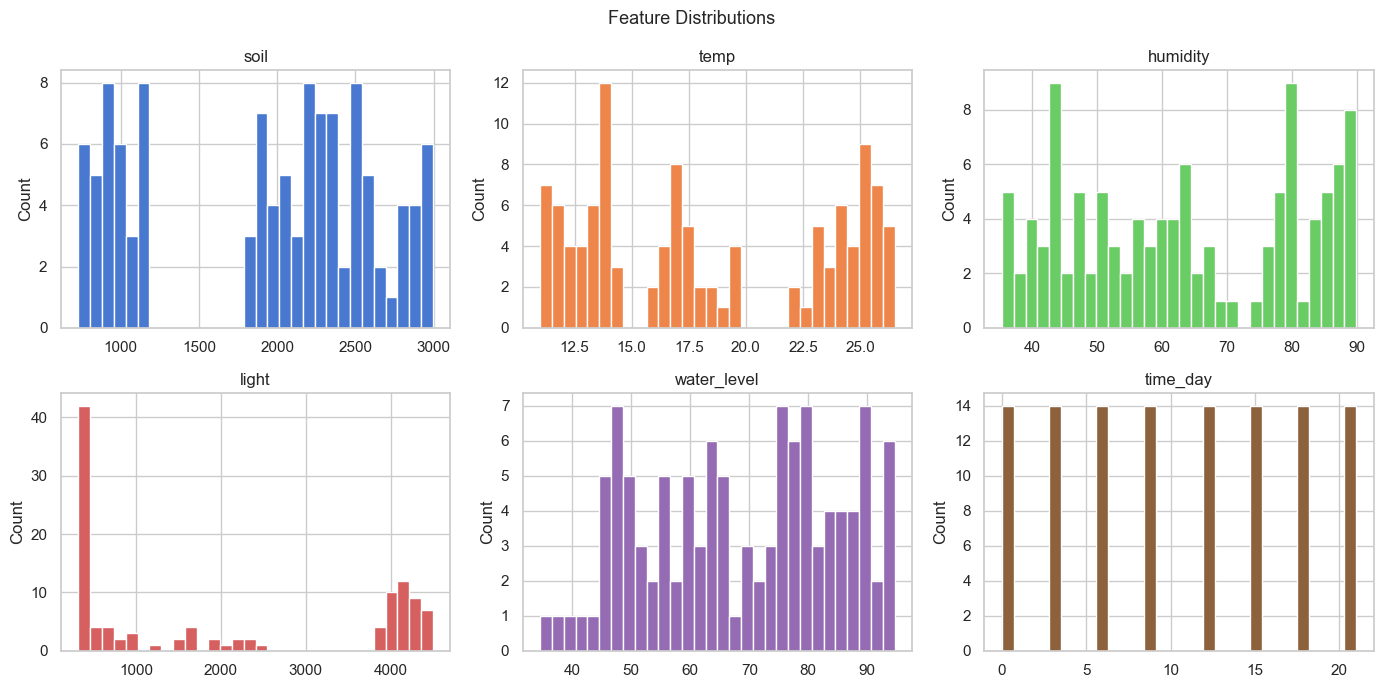

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

colors = sns.color_palette('muted', len(FEATURES))
for i, col in enumerate(FEATURES):
    axes[i].hist(df[col], bins=30, color=colors[i], edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

### 3c — Correlation Heatmap

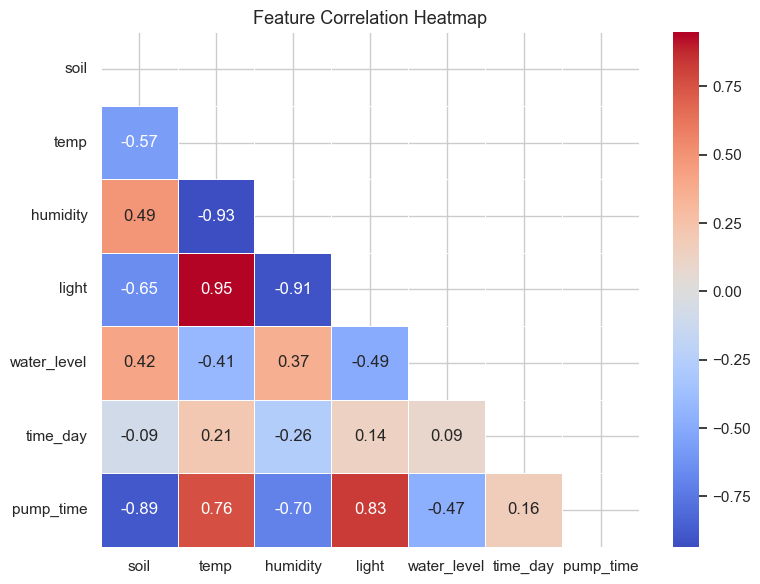

In [42]:
corr = df[FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

### 3d — Feature vs Target Scatter Plots

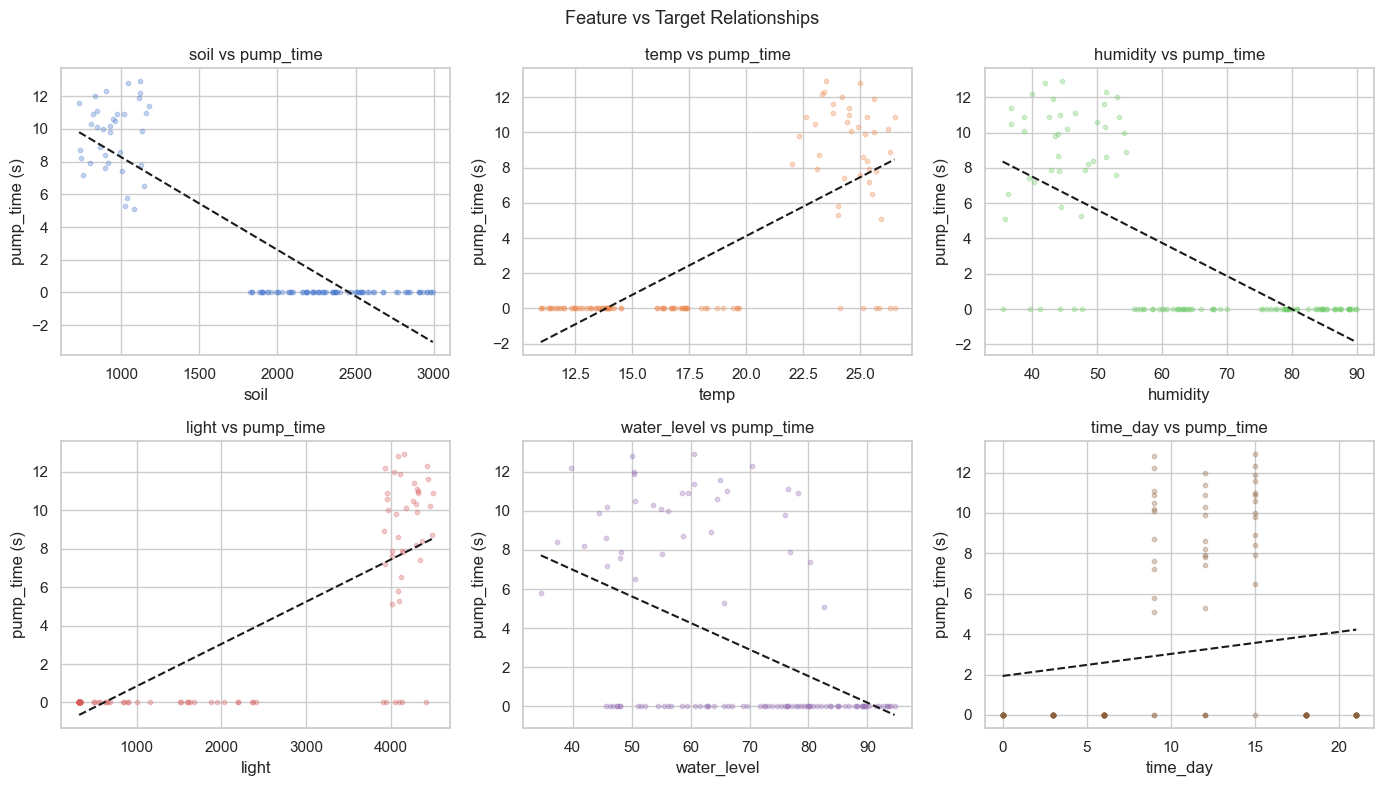

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    axes[i].scatter(df[col], df[TARGET], alpha=0.3, s=10, color=colors[i])
    # trend line
    z = np.polyfit(df[col], df[TARGET], 1)
    p = np.poly1d(z)
    x_sorted = np.linspace(df[col].min(), df[col].max(), 200)
    axes[i].plot(x_sorted, p(x_sorted), 'k--', linewidth=1.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('pump_time (s)')
    axes[i].set_title(f'{col} vs pump_time')

plt.suptitle('Feature vs Target Relationships', fontsize=13)
plt.tight_layout()
plt.show()

## 4 — Train / Test Split & Scaling

In [44]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (89, 6)  |  Test: (23, 6)


## 5 — Train Model

In [45]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_sc, y_train)
print('Training complete')

Training complete


## 6 — Evaluation Metrics

In [46]:
pred = model.predict(X_test_sc)

mae = mean_absolute_error(y_test, pred)
r2  = r2_score(y_test, pred)
residuals = y_test.values - pred

print(f'MAE : {mae:.2f} s')
print(f'R²  : {r2:.4f}')
print(f'RMSE: {np.sqrt(np.mean(residuals**2)):.2f} s')

MAE : 0.60 s
R²  : 0.8868
RMSE: 1.41 s


## 7 — Prediction Analysis Plots

### 7a — Actual vs Predicted

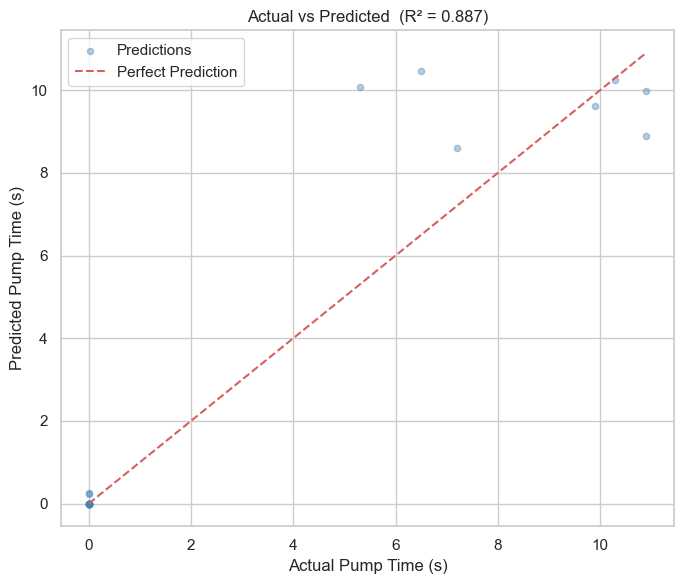

In [47]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, pred, alpha=0.4, s=20, color='steelblue', label='Predictions')
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Pump Time (s)')
ax.set_ylabel('Predicted Pump Time (s)')
ax.set_title(f'Actual vs Predicted  (R² = {r2:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

### 7b — Residuals Analysis

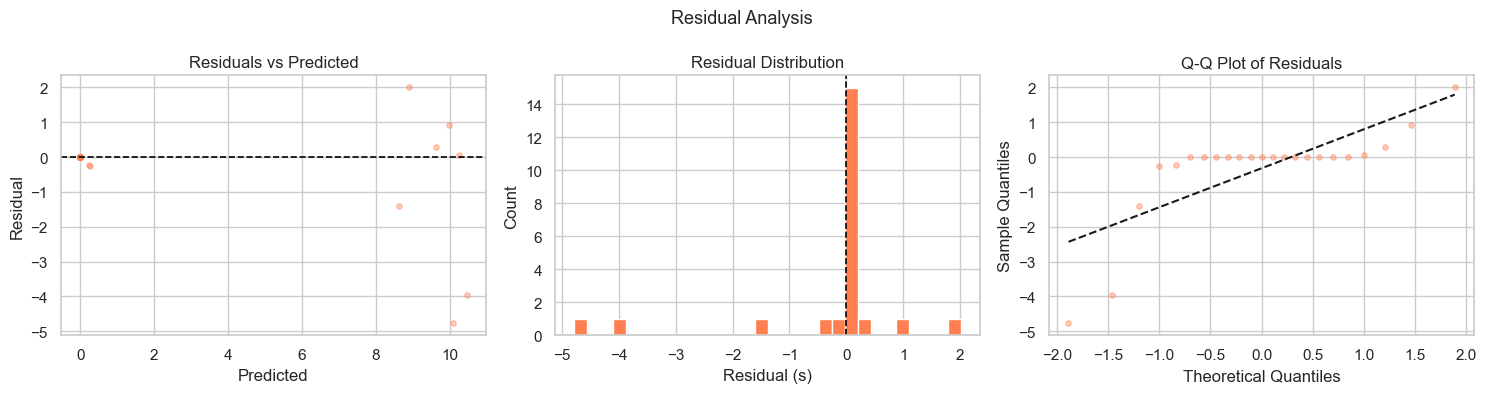

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs Predicted
axes[0].scatter(pred, residuals, alpha=0.4, s=15, color='coral')
axes[0].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

# Residual Distribution
axes[1].hist(residuals, bins=30, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Residual (s)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

# Q-Q plot
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals)
axes[2].scatter(osm, osr, alpha=0.4, s=15, color='coral')
axes[2].plot(osm, slope * np.array(osm) + intercept, 'k--', linewidth=1.5)
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')
axes[2].set_title('Q-Q Plot of Residuals')

plt.suptitle('Residual Analysis', fontsize=13)
plt.tight_layout()
plt.show()

## 8 — Feature Importance

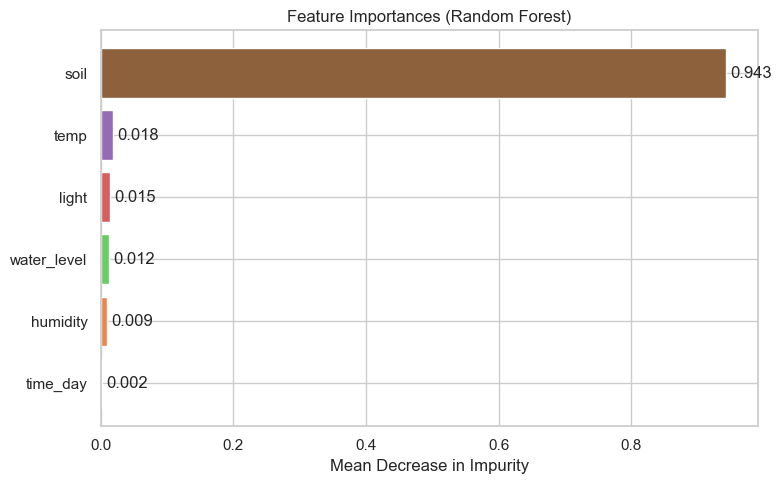

In [49]:
importances = model.feature_importances_
idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    [FEATURES[i] for i in idx],
    importances[idx],
    color=sns.color_palette('muted', len(FEATURES))
)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

## 9 — Learning Curve

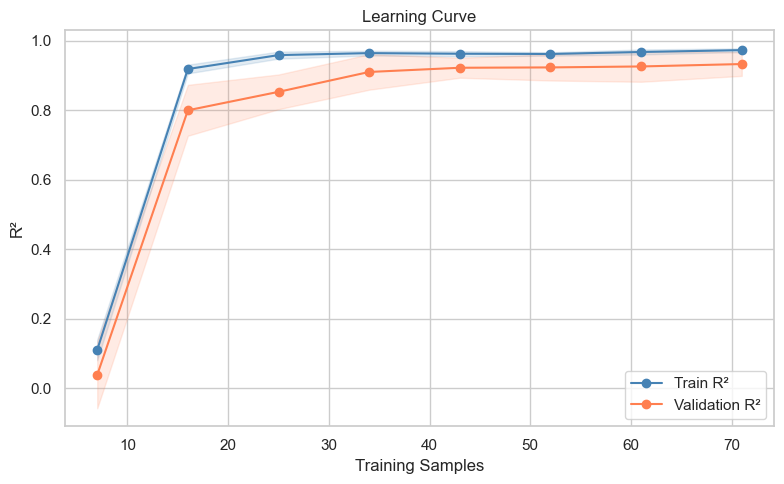

In [51]:
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train_sc, y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

t_mean, t_std = train_scores.mean(1), train_scores.std(1)
v_mean, v_std = val_scores.mean(1),   val_scores.std(1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, t_mean, 'o-', label='Train R²',      color='steelblue')
ax.fill_between(train_sizes, t_mean - t_std, t_mean + t_std, alpha=0.15, color='steelblue')
ax.plot(train_sizes, v_mean, 'o-', label='Validation R²', color='coral')
ax.fill_between(train_sizes, v_mean - v_std, v_mean + v_std, alpha=0.15, color='coral')
ax.set_xlabel('Training Samples')
ax.set_ylabel('R²')
ax.set_title('Learning Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 10 — Prediction Error Distribution

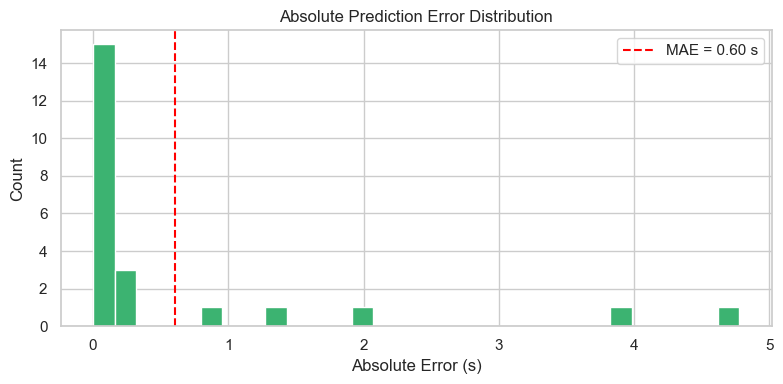

Errors within 1 s  : 82.6%
Errors within 2 s  : 87.0%
Errors within 5 s  : 100.0%


In [52]:
abs_err = np.abs(residuals)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(abs_err, bins=30, color='mediumseagreen', edgecolor='white', cumulative=False)
ax.axvline(mae, color='red', linestyle='--', linewidth=1.5, label=f'MAE = {mae:.2f} s')
ax.set_xlabel('Absolute Error (s)')
ax.set_ylabel('Count')
ax.set_title('Absolute Prediction Error Distribution')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Errors within 1 s  : {(abs_err <= 1).mean()*100:.1f}%')
print(f'Errors within 2 s  : {(abs_err <= 2).mean()*100:.1f}%')
print(f'Errors within 5 s  : {(abs_err <= 5).mean()*100:.1f}%')

## 11 — Save Model

In [53]:
joblib.dump(model,  'irrigation_model_last2.pkl')
joblib.dump(scaler, 'irrigation_scaler_last2.pkl')
print('Saved: irrigation_model_last2.pkl')
print('Saved: irrigation_scaler_last2.pkl')

Saved: irrigation_model_last2.pkl
Saved: irrigation_scaler_last2.pkl


## 12 — Predict Function & Test

In [54]:
def predict_irrigation(soil, temp, humidity, light, water_level, time_day):
    X_new = pd.DataFrame([{
        'soil': soil, 'temp': temp, 'humidity': humidity,
        'light': light, 'water_level': water_level, 'time_day': time_day
    }])
    pump = model.predict(scaler.transform(X_new))[0]
    return round(float(np.clip(pump, PUMP_MIN_TIME, PUMP_MAX_TIME)), 1)


result = predict_irrigation(
    soil=1000, temp=10, humidity=100,
    light=100, water_level=10, time_day=9
)
print(f'Predicted pump time: {result} seconds')

Predicted pump time: 8.4 seconds
